In [1]:
include("PermBasis.jl")
include("PlotSetup.jl")
include("MonteCarloMF.jl")
using PyPlot
using DifferentialEquations
using JLD2

legend_kwargs = (
    fontsize=12,
    framealpha=0.9,
    borderpad=0.3,
    labelspacing=0.3,
    handlelength=2.0
)


(fontsize = 12, framealpha = 0.9, borderpad = 0.3, labelspacing = 0.3, handlelength = 2.0)

In [2]:
struct NullAxis end

function Base.getproperty(::NullAxis, name::Symbol)
    return (args...; kwargs...) -> nothing
end

stub = NullAxis()

NullAxis()

In [3]:
function plot_mf_sweep!(ax;
    N = 10^8,
    rs = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1],
    cmap_name = "turbo"
)
    cmap = get_cmap(cmap_name)
    norm = matplotlib.colors.Normalize(vmin=minimum(rs), vmax=maximum(rs))

    tmax = 2000.0 * log(N) / N

    for r in rs
        params = Dict(
            "global_decay" => 1.0,
            "global_pump" => 0.0,
            "local_pump" => 0.0,
            "local_dephasing" => r * N,
            "local_decay" => 0.0 * N,
        )

        p = [params["global_decay"], params["local_dephasing"], N, params["local_decay"]]
        u0 = [1 / N, 1 / 2]
        prob = ODEProblem(meanfield_reduced!, u0, (0.0, tmax), p)

        ts = exp.(range(log(1e-12), log(tmax), length=100000))

        mfsol = solve(
            prob,
            AutoTsit5(Rosenbrock23()),
            reltol=1e-15,
            abstol=1e-15,
            saveat=ts
        )

        color = cmap(norm(r))

        ax.plot(
            mfsol.t / log(N) * N,
            4 * element(mfsol, 1);
            color=color,
            linestyle="solid",
            linewidth=2.0,
            label=L"g_\xi = %$r"
        )

        Intens = 4 * element(mfsol, 1)
        tau = mfsol.t / log(N) * N

        idx = argmax(Intens)
        ax.plot(tau[idx], Intens[idx];
            marker="*",
            markersize=10,
            color=color,
            linestyle="none"
        )
    end

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylim(bottom=4e-10, top = 2)
    ax.set_xlim(left = 1e-2)
    ax.set_xlabel(L"t\Gamma N/\log N")
    ax.set_ylabel(L"I_{\star}/I_\star^{\rm{(Dicke)}}")
    

    return ax
end

function plot_mf_trajectories_SM!(ax;
    N = 10^8,
    rs = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1],
    cmap_name = "turbo",
    triangle_alpha = 0.12
)
    cmap = get_cmap(cmap_name)
    norm = matplotlib.colors.Normalize(vmin=minimum(rs), vmax=maximum(rs))

    # Dicke triangle:
    # 0 <= S/N <= 1/2
    # -S/N <= M/N <= S/N
    sgrid = range(0.0, 0.5, length=400)


    # Boundary lines of the allowed region
    ax.plot(sgrid, sgrid; color="black", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.plot(sgrid, .-sgrid; color="black", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.plot([0.0, 0.5], [0.0, 0.0]; color="black", linestyle=":", linewidth=0.8, alpha=0.5)

    tmax = 2000.0 * log(N) / N

    for r in rs
        params = Dict(
            "global_decay" => 1.0,
            "global_pump" => 0.0,
            "local_pump" => 0.0,
            "local_dephasing" => r * N,
            "local_decay" => 0.0 * N,
        )

        p = [params["global_decay"], params["local_dephasing"], N, params["local_decay"]]
        u0 = [1 / N, 1 / 2]
        prob = ODEProblem(meanfield_reduced!, u0, (0.0, tmax), p)

        ts = exp.(range(log(1e-12), log(tmax), length=100000))

        mfsol = solve(
            prob,
            AutoTsit5(Rosenbrock23()),
            reltol=1e-15,
            abstol=1e-15,
            saveat=ts
        )

        # Convention assumed:
        # u[1] = I / N^2 = (S/N)^2 - (M/N)^2
        # u[2] = M / N
        Inorm = element(mfsol, 1)
        Mnorm = element(mfsol, 2)
        Snorm = sqrt.(max.(Inorm .+ Mnorm.^2, 0.0))

        color = cmap(norm(r))

        ax.plot(
            Snorm,
            Mnorm;
            color=color,
            linestyle="solid",
            linewidth=2.0,
            label=L"g_\xi = %$r"
        )

        i = argmin(abs.(Mnorm .- 0.2))
        if i == length(Mnorm) continue end

        ax.annotate(
            "",
            xy=(Snorm[i+1], Mnorm[i+1]),
            xytext=(Snorm[i-1], Mnorm[i-1]),
            arrowprops=Dict(
                "arrowstyle" => "->",
                "color" => color,
                "lw" => 2.0
            )
        )
    end

    sgrid = range(0.0, 0.52, length=400)

    ymax = 0.52
    ymin = -0.52

    # Forbidden regions
    ax.fill_between(sgrid, sgrid, ymax; color="gray", alpha=triangle_alpha, linewidth=0)
    ax.fill_between(sgrid, ymin, .-sgrid; color="gray", alpha=triangle_alpha, linewidth=0)
    # Entire strip x > 0.5 is forbidden
    ax.axvspan(0.5, 0.52; color="gray", alpha=triangle_alpha, linewidth=0)

    ax.set_xlim(0.0, 0.52)
    ax.set_ylim(-0.52, 0.52)
    ax.set_xlabel(L"S/N")
    ax.set_ylabel(L"M/N")

    ax.set_xticks([0.0, 0.5])
    ax.set_yticks([-0.5, 0.0, 0.5])

    ax.set_xticklabels([L"0", L"\tfrac12"])
    ax.set_yticklabels([L"-\tfrac12", L"0", L"\tfrac12"])
    
    return ax
end

function plot_peak_observables!(ax1, ax2;
    N = 10^8,
    rs_mark = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1],
    cmap_name = "turbo"
)
    rs = sort(unique(vcat(range(0.0, 1.2, length=200)..., rs_mark...)))

    cmap = get_cmap(cmap_name)
    norm = matplotlib.colors.Normalize(vmin=minimum(rs), vmax=maximum(rs))

    tmax = 2000.0 * log(N) / N

    tpeaks = Float64[]
    Ipeaks = Float64[]

    for r in rs
        params = Dict(
            "global_decay" => 1.0,
            "global_pump" => 0.0,
            "local_pump" => 0.0,
            "local_dephasing" => r * N,
            "local_decay" => 0.0 * N,
        )

        p = [params["global_decay"], params["local_dephasing"], N, params["local_decay"]]
        u0 = [1 / N, 1 / 2]
        prob = ODEProblem(meanfield_reduced!, u0, (0.0, tmax), p)

        ts = range(0.0, tmax, length=100000)

        mfsol = solve(
            prob,
            AutoTsit5(Rosenbrock23()),
            reltol=1e-15,
            abstol=1e-15,
            saveat=ts
        )

        Ivals = 4 * element(mfsol, 1)
        imax = argmax(Ivals)

        push!(tpeaks, mfsol.t[imax] * N / log(N))
        push!(Ipeaks, Ivals[imax])
    end

    # --- Ipeaks ---
    ax1.plot(rs, Ipeaks, color="black", linewidth=1.5)

    for r in rs_mark
        idx = argmin(abs.(rs .- r))
        color = cmap(norm(r))
        ax1.plot(rs[idx], Ipeaks[idx];
            marker="*",
            markersize=10,
            color=color,
            linestyle="none"
        )
    end

    ax1.set_xlabel(L"\xi/(N\Gamma)")
    ax1.set_ylabel(L"I_{\star}/I_\star^{\rm{(Dicke)}}")

    # --- tpeaks ---
    ax2.plot(rs, tpeaks, color="black", linewidth=1.5)

    for r in rs_mark
        idx = argmin(abs.(rs .- r))
        color = cmap(norm(r))
        ax2.plot(rs[idx], tpeaks[idx];
            marker="*",
            markersize=10,
            color=color,
            linestyle="none"
        )
    end

    ax2.set_xlabel(L"\xi/(N\Gamma)")
    ax2.set_ylabel(L"N t_\star / \log N")
    ax2.set_ylim(top=10.0, bottom=-0.2)

    return ax1, ax2
end

plot_peak_observables! (generic function with 1 method)

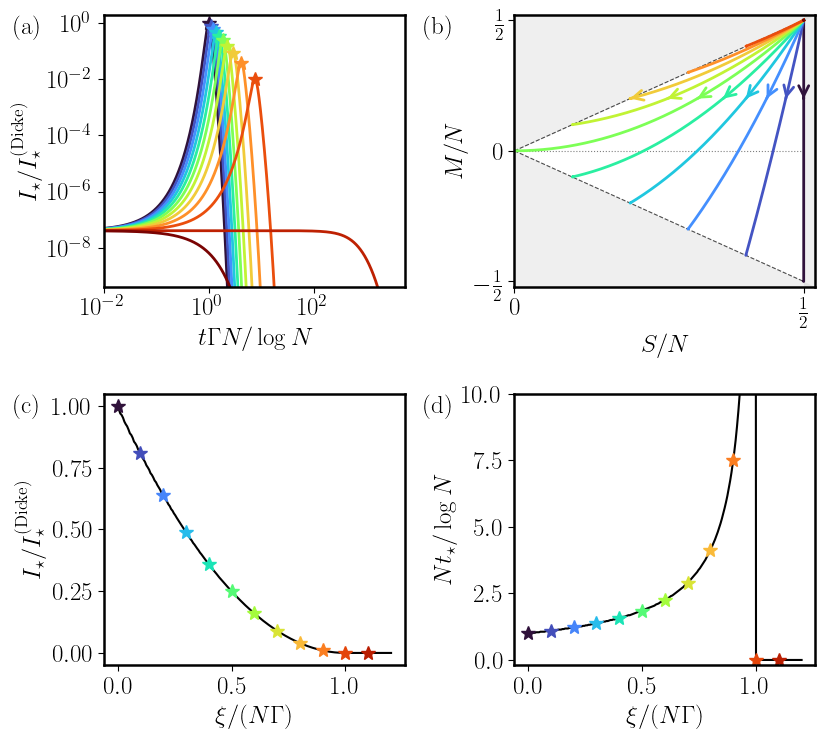

PyObject Text(-0.3, 1.0, '(d)')

In [4]:
fig, axes = subplots(ncols = 2, nrows = 2, figsize = 2.0 .* latex_plot_setup(ratio=0.9, scale=1.8))
ax1, ax3, ax2, ax4 = axes
plot_mf_sweep!(ax1)
plot_mf_trajectories_SM!(ax2)
plot_peak_observables!(ax3, ax4)
tight_layout()

axes[1,1].text(-0.3, 1.0, "(a)", transform=axes[1,1].transAxes, va="top")
axes[1,2].text(-0.3, 1.0, "(b)", transform=axes[1,2].transAxes, va="top")
axes[2,1].text(-0.3, 1.0, "(c)", transform=axes[2,1].transAxes, va="top")
axes[2,2].text(-0.3, 1.0, "(d)", transform=axes[2,2].transAxes, va="top")

In [5]:
function plot_mf_sweep_gamma!(ax;
    N = 10^8,
    gbar_vals = [0.0, 0.02, 0.04, 0.06, 0.08, 0.1],
    cmap_name = "turbo",
    c = 2000.0,
    d = 1e-12
)
    cmap = get_cmap(cmap_name)
    norm = matplotlib.colors.Normalize(vmin=minimum(gbar_vals), vmax=maximum(gbar_vals))

    tmax = c * log(N) / N

    for gbar in gbar_vals
        γ = gbar * N / log(N)

        params = Dict(
            "global_decay" => 1.0,
            "global_pump" => 0.0,
            "local_pump" => 0.0,
            "local_dephasing" => 0.0,
            "local_decay" => γ,
        )

        p = [params["global_decay"], params["local_dephasing"], N, params["local_decay"]]
        u0 = [1 / N, 1 / 2]
        prob = ODEProblem(meanfield_reduced!, u0, (0.0, tmax), p)

        ts = exp.(range(log(d), log(tmax), length=100000))

        mfsol = solve(
            prob,
            AutoTsit5(Rosenbrock23()),
            reltol=1e-15,
            abstol=1e-15,
            saveat=ts
        )

        color = cmap(norm(gbar))

        ax.plot(
            mfsol.t / log(N) * N,
            4 * element(mfsol, 1);
            color=color,
            linewidth=2.0,
            linestyle = "solid",
            label=L"\bar g_\gamma = %$gbar"
        )

        Intens = 4 * element(mfsol, 1)
        tau = mfsol.t / log(N) * N

        idx = argmax(Intens)
        ax.plot(tau[idx], Intens[idx];
            marker="*",
            markersize=10,
            color=color,
            linestyle="none"
        )
    end

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylim(bottom=1e-10, top = 2)
    ax.set_xlim(left = 1e-2)
    ax.set_xlabel(L"t\Gamma N/\log N")
    ax.set_ylabel(L"I_{\star}/I_\star^{\rm{(Dicke)}}")

    return ax
end

function plot_mf_trajectories_SM_gamma!(ax;
    N = 10^8,
    gbar_vals = [0.0, 0.02, 0.04, 0.06, 0.08, 0.1],
    cmap_name = "turbo",
    triangle_alpha = 0.12,
    c = 2000.0,
    d = 1e-12,
    r = 0.0
)
    cmap = get_cmap(cmap_name)
    norm = matplotlib.colors.Normalize(vmin=minimum(gbar_vals), vmax=maximum(gbar_vals))

    sgrid = range(0.0, 0.5, length=400)

    ax.plot(sgrid, sgrid; color="black", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.plot(sgrid, .-sgrid; color="black", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.plot([0.0, 0.5], [0.0, 0.0]; color="black", linestyle=":", linewidth=0.8, alpha=0.5)

    tmax = c * log(N) / N

    for gbar in gbar_vals
        γ = gbar * N / log(N)

        params = Dict(
            "global_decay" => 1.0,
            "global_pump" => 0.0,
            "local_pump" => 0.0,
            "local_dephasing" => r * N,
            "local_decay" => γ,
        )

        p = [params["global_decay"], params["local_dephasing"], N, params["local_decay"]]
        u0 = [log(1 / N), 1 / 2]
        prob = ODEProblem(meanfield_log_transformed!, u0, (0.0, tmax), p)

        ts = exp.(range(log(d), log(tmax), length=100000))

        mfsol = solve(
            prob,
            AutoTsit5(Rosenbrock23()),
            reltol=1e-15,
            abstol=1e-15,
            saveat=ts
        )

        Inorm = exp.(element(mfsol, 1))
        Mnorm = element(mfsol, 2)
        Snorm = sqrt.(max.(Inorm .+ Mnorm.^2, 0.0))

        color = cmap(norm(gbar))

        ax.plot(
            Snorm,
            Mnorm;
            color=color,
            linewidth=2.0,
            linestyle="solid",
            label=L"\bar g_\gamma = %$gbar"
        )

        i = argmin(abs.(Mnorm .+ 0.1))

        ax.annotate(
            "",
            xy=(Snorm[i+1], Mnorm[i+1]),
            xytext=(Snorm[i-1], Mnorm[i-1]),
            arrowprops=Dict(
                "arrowstyle" => "->",
                "color" => color,
                "lw" => 2.0
            )
        )
    end

    sgrid = range(0.0, 0.52, length=400)
    ymax = 0.52

    ax.fill_between(sgrid, sgrid, ymax; color="gray", alpha=triangle_alpha, linewidth=0)
    ax.fill_between(sgrid, -ymax, .-sgrid; color="gray", alpha=triangle_alpha, linewidth=0)
    ax.axvspan(0.5, 0.52; color="gray", alpha=triangle_alpha, linewidth=0)

    ax.set_xlim(0.0, 0.52)
    ax.set_ylim(-0.52, 0.52)
    ax.set_xlabel(L"S/N")
    ax.set_ylabel(L"M/N")

        
    ax.set_xticks([0.0, 0.5])
    ax.set_yticks([-0.5, 0.0, 0.5])

    ax.set_xticklabels([L"0", L"\tfrac12"])
    ax.set_yticklabels([L"-\tfrac12", L"0", L"\tfrac12"])

    return ax
end


function plot_peak_observables_gamma!(ax1, ax2;
    N = 10^8,
    gbar_mark = [0.0, 0.02, 0.04, 0.06, 0.08, 0.1],
    cmap_name = "turbo",
    c = 2000.0,
    N_asymptotic = nothing,
    gbar_asymptotic = nothing,
    asymptotic_color = "black",
    asymptotic_linestyle = "--",
    asymptotic_linewidth = 1.2
)
    cmap = get_cmap(cmap_name)

    function compute_peak_curves(Nloc, gbar_vals)
        tmax = Float64(c * log(Nloc) / Nloc)

        tpeaks = Float64[]
        Ipeaks = Float64[]

        for gbar in gbar_vals
            γ = Float64(gbar * Nloc / log(Nloc))

            params = Dict(
                "global_decay" => 1.0,
                "global_pump" => 0.0,
                "local_pump" => 0.0,
                "local_dephasing" => 0.0,
                "local_decay" => γ,
            )

            p = [params["global_decay"], params["local_dephasing"], Nloc, params["local_decay"]]
            u0 = [Float64(log(1 / Nloc)), 1 / 2]
            prob = ODEProblem(meanfield_log_transformed!, u0, (0.0, tmax), p)

            ts = range(0.0, tmax, length=100000)

            mfsol = solve(
                prob,
                AutoTsit5(Rosenbrock23()),
                reltol=1e-15,
                abstol=1e-15,
                saveat=ts
            )

            Ivals = 4 * exp.(element(mfsol, 1))
            imax = argmax(Ivals)

            push!(tpeaks, mfsol.t[imax] * Float64(Nloc / log(Nloc)))
            push!(Ipeaks, Ivals[imax])
        end

        return Ipeaks, tpeaks
    end

    # marked / finite-N curve
    gbar_vals = sort(unique(vcat(range(0.0, maximum(gbar_mark), length=200)..., gbar_mark...)))
    norm = matplotlib.colors.Normalize(vmin=minimum(gbar_vals), vmax=maximum(gbar_vals))

    Ipeaks, tpeaks = compute_peak_curves(N, gbar_vals)

    ax1.plot(gbar_vals, Ipeaks;
        color="black", linewidth=1.5, linestyle="solid", label = L"N=10^8"
    )
    ax2.plot(gbar_vals, tpeaks;
        color="black", linewidth=1.5, linestyle="solid", label = L"N=10^8"
    )

    for gbar in gbar_mark
        idx = argmin(abs.(gbar_vals .- gbar))
        color = cmap(norm(gbar))

        ax1.plot(gbar_vals[idx], Ipeaks[idx];
            marker="*",
            markersize=10,
            color=color,
            linestyle="none"
        )
        ax2.plot(gbar_vals[idx], tpeaks[idx];
            marker="*",
            markersize=10,
            color=color,
            linestyle="none"
        )
    end

    # optional asymptotic curve
    if N_asymptotic !== nothing
        gbar_asymptotic === nothing && (gbar_asymptotic = range(0.0, maximum(gbar_mark), length=400))
        Ipeaks_asym, tpeaks_asym = compute_peak_curves(N_asymptotic, collect(gbar_asymptotic))

        ax1.plot(gbar_asymptotic, Ipeaks_asym;
            color=asymptotic_color,
            linewidth=asymptotic_linewidth,
            linestyle=asymptotic_linestyle,
            label = L"N\to\infty"
        )
        ax2.plot(gbar_asymptotic, tpeaks_asym;
            color=asymptotic_color,
            linewidth=asymptotic_linewidth,
            linestyle=asymptotic_linestyle,
            label = L"N\to\infty"
        )
    end

    ax1.set_xlabel(L"\gamma\log N/(N\Gamma)")
    ax1.set_ylabel(L"I_{\star}/I_\star^{\rm{(Dicke)}}")
    ax1.legend(;legend_kwargs...)

    ax2.set_xlabel(L"\gamma\log N/(N\Gamma)")
    ax2.set_ylabel(L"N t_\star / \log N")
    ax2.legend(;legend_kwargs...)

    return ax1, ax2
end



plot_peak_observables_gamma! (generic function with 1 method)

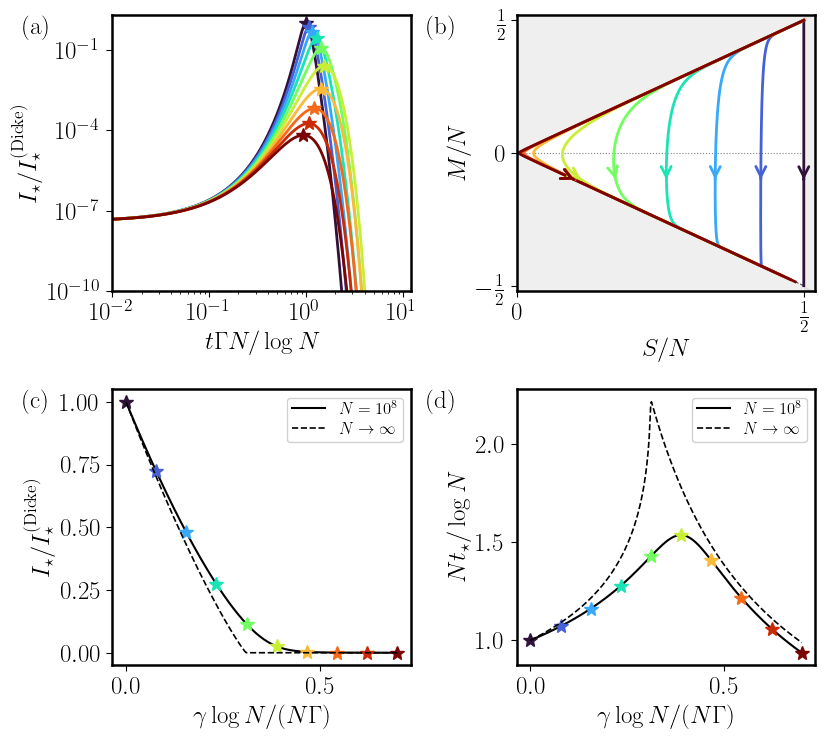

PyObject Text(-0.3, 1.0, '(d)')

In [6]:
fig, axes = subplots(
    ncols=2, nrows=2,
    figsize=2.0 .* latex_plot_setup(ratio=0.9, scale=1.8)
)

ax1, ax3, ax2, ax4 = axes
N = 10^8
Nas = BigFloat(10)^300

# --- explicit parameter arrays ---
gbar_vals = range(0.0, 0.7, 10)
gbar_mark = gbar_vals

# optional knobs
c = 6.0
d = 1e-12

# if you want gamma instead, swap:
plot_mf_sweep_gamma!(ax1; gbar_vals=gbar_vals, c=c, d=d, N = N)
plot_mf_trajectories_SM_gamma!(ax2; gbar_vals=gbar_vals, c=c, d=d, N = N)
plot_peak_observables_gamma!(ax3, ax4; gbar_mark=gbar_mark, c=c, N = N, N_asymptotic = Nas)

tight_layout()

axes[1,1].text(-0.3, 1.0, "(a)", transform=axes[1,1].transAxes, va="top")
axes[1,2].text(-0.3, 1.0, "(b)", transform=axes[1,2].transAxes, va="top")
axes[2,1].text(-0.3, 1.0, "(c)", transform=axes[2,1].transAxes, va="top")
axes[2,2].text(-0.3, 1.0, "(d)", transform=axes[2,2].transAxes, va="top")

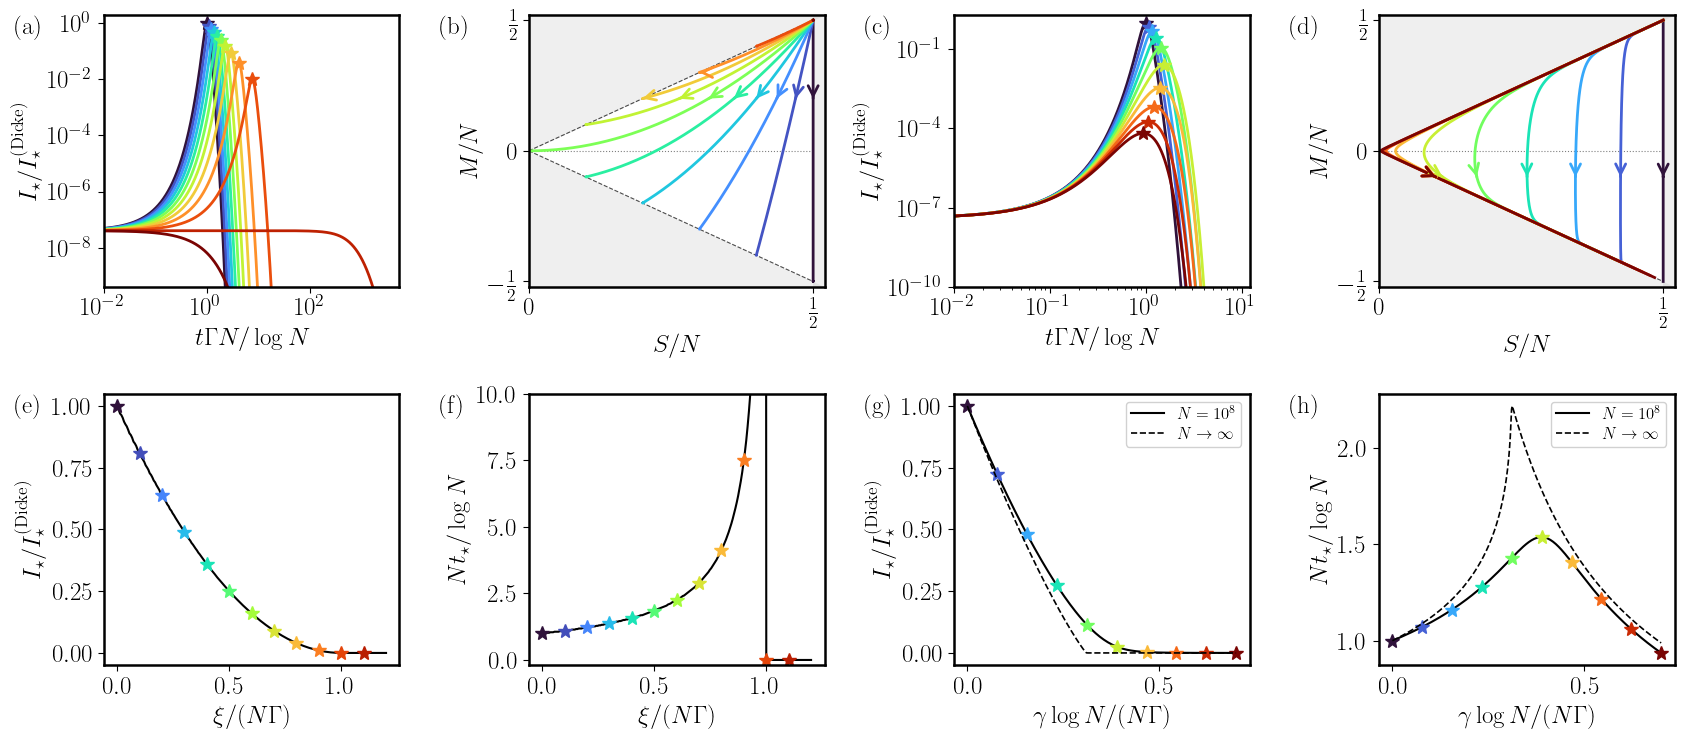

In [7]:
w, h = latex_plot_setup(ratio=0.9, scale=1.8)
fig, axes = subplots(ncols = 4, nrows = 2, figsize = (4 * w, 2 * h))
ax1, ax3, ax2, ax4 = axes
plot_mf_sweep!(axes[1,1])
plot_mf_trajectories_SM!(axes[1,2])
plot_peak_observables!(axes[2,1], axes[2,2])

plot_mf_sweep_gamma!(axes[1,3]; gbar_vals=gbar_vals, c=c, d=d, N = N)
plot_mf_trajectories_SM_gamma!(axes[1,4]; gbar_vals=gbar_vals, c=c, d=d, N = N)
plot_peak_observables_gamma!(axes[2,3], axes[2,4]; gbar_mark=gbar_mark, c=c, N = N, N_asymptotic = Nas)

tight_layout()

axes[1,1].text(-0.3, 1.0, "(a)", transform=axes[1,1].transAxes, va="top")
axes[1,2].text(-0.3, 1.0, "(b)", transform=axes[1,2].transAxes, va="top")
axes[2,1].text(-0.3, 1.0, "(e)", transform=axes[2,1].transAxes, va="top")
axes[2,2].text(-0.3, 1.0, "(f)", transform=axes[2,2].transAxes, va="top")

axes[1,3].text(-0.3, 1.0, "(c)", transform=axes[1,3].transAxes, va="top")
axes[1,4].text(-0.3, 1.0, "(d)", transform=axes[1,4].transAxes, va="top")
axes[2,3].text(-0.3, 1.0, "(g)", transform=axes[2,3].transAxes, va="top")
axes[2,4].text(-0.3, 1.0, "(h)", transform=axes[2,4].transAxes, va="top")

savefig("../data/fig2.pdf", bbox_inches = "tight")


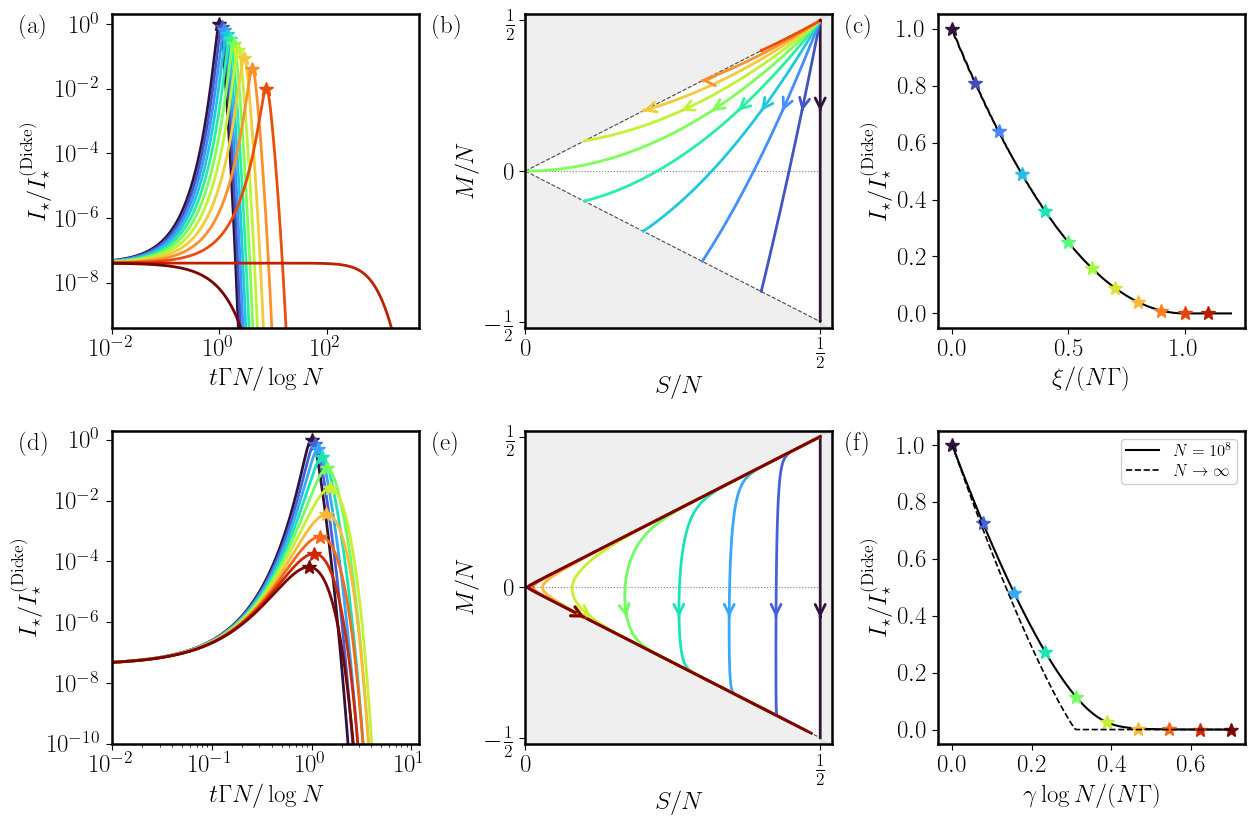

In [8]:
cmap_name = "turbo"
w, h = latex_plot_setup(ratio=1.0, scale=1.8)
fig, axes = subplots(ncols = 3, nrows = 2, figsize = (3 * w, 2 * h))
stub = NullAxis()

plot_mf_sweep!(axes[1,1]; cmap_name = cmap_name)
plot_mf_trajectories_SM!(axes[1,2]; cmap_name = cmap_name)
plot_peak_observables!(axes[1,3], stub; cmap_name = cmap_name)

plot_mf_sweep_gamma!(axes[2,1]; gbar_vals=gbar_vals, c=c, d=d, N = N, cmap_name = cmap_name)
plot_mf_trajectories_SM_gamma!(axes[2,2]; gbar_vals=gbar_vals, c=c, d=d, N = N, cmap_name = cmap_name)
plot_peak_observables_gamma!(axes[2,3], stub; gbar_mark=gbar_mark, c=c, N = N, N_asymptotic = Nas, cmap_name = cmap_name)

tight_layout()

axes[1,1].text(-0.3, 1.0, "(a)", transform=axes[1,1].transAxes, va="top")
axes[1,2].text(-0.3, 1.0, "(b)", transform=axes[1,2].transAxes, va="top")
axes[1,3].text(-0.3, 1.0, "(c)", transform=axes[1,3].transAxes, va="top")
axes[2,1].text(-0.3, 1.0, "(d)", transform=axes[2,1].transAxes, va="top")
axes[2,2].text(-0.3, 1.0, "(e)", transform=axes[2,2].transAxes, va="top")
axes[2,3].text(-0.3, 1.0, "(f)", transform=axes[2,3].transAxes, va="top")
savefig("../data/fig2.pdf", bbox_inches = "tight")


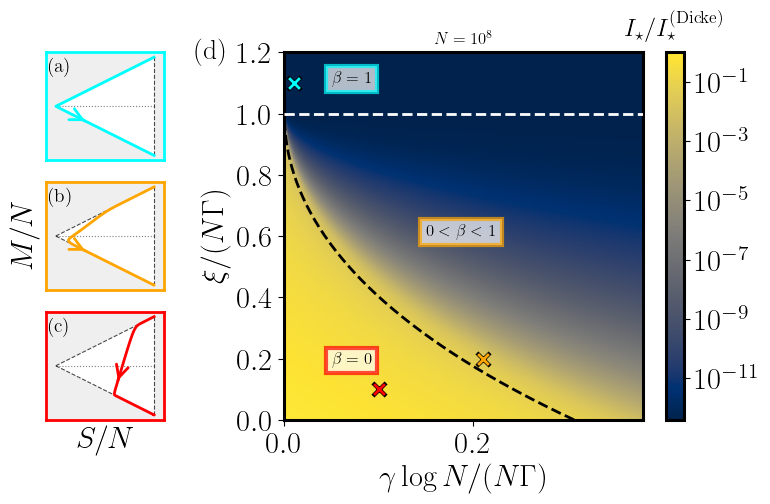

In [9]:
function generate_spont_phase_diagram_data(;
    outfile = "../plot_data/spont_phase_diagram.jld2",
    gs = range(0.0, 0.38, 200),
    rs = range(0.0, 1.2, 200),
    pow = 200,
    reltol = 1e-8,
    abstol = 1e-10,
)
    N = BigInt(10)^pow
    Nf = Float64(N)

    data = zeros(length(rs), length(gs))

    for (i, r) in enumerate(rs)
        for (j, g) in enumerate(gs)
            Γ = 1.0
            ξ = Nf * r
            γ = Nf * g / log(Nf)

            p = [Γ, ξ, Nf, γ]
            u0 = [-log(Nf), 0.5]
            t_end = 100.0 * log(Nf) / Nf

            prob = ODEProblem(meanfield_log_transformed!, u0, (0.0, t_end), p)
            sol = solve(
                prob,
                AutoTsit5(Rosenbrock23()),
                reltol = reltol,
                abstol = abstol,
                saveat = range(0.0, t_end, 30000)
            )

            data[i, j] = exp(maximum(x -> x[1], sol.u))
        end
    end

    jldsave(outfile;
        gs = collect(gs),
        rs = collect(rs),
        data = data,
        pow = pow,
        N = string(N),
    )
end

function analytic_spont_boundary(rs)
    return (1 .- rs) .- (1 .+ rs) .* log.(2 ./ (1 .+ rs))
end

function plot_spont_phase_diagram!(
    ax,
    d;
    contour_tol = 1e-2,
    show_analytic_boundary = true,
    rescale_intensity = 4.0,
    cmap = "viridis",
    add_colorbar = true,
    colorbar_label = L"$I/N^2$",
    analytic_color = "white",
    analytic_linestyle = "--",
)
    gs = d["gs"]
    rs = d["rs"]
    data = d["data"]

    norm = matplotlib.colors.LogNorm(
    vmin = maximum([minimum(rescale_intensity .* data), contour_tol]),
    vmax = maximum(rescale_intensity .* data)
    )

    im = ax.imshow(
        rescale_intensity .* data,
        extent = [first(gs), last(gs), first(rs), last(rs)],
        origin = "lower",
        aspect = "auto",
        cmap = cmap,
        norm = norm
            )

    if show_analytic_boundary
        rb = collect(rs)
        gb = analytic_spont_boundary(rb)
        valid = (gb .>= minimum(gs)) .& (gb .<= maximum(gs)) .& (rs .< 1.0)
        ax.plot(gb[valid], rb[valid], color = "black", linestyle = analytic_linestyle, linewidth = 2.0, zorder = 11, label = L"\beta=0\text{ boundary}")

        y = similar(gs); y .= 1.0
        ax.plot(gs, y, color = analytic_color, linestyle = analytic_linestyle, linewidth = 2.0, zorder = 11, label = L"\beta=1\text{ boundary}")
        bbox = Dict("facecolor" => "white", "edgecolor" => "red", "alpha" => 0.7, "pad" => 4, "linewidth" => 3)
        ax.text(0.05, 0.18, L"\beta=0", color = "black", fontsize = legend_kwargs.fontsize, zorder = 11, bbox = bbox)
        bbox = Dict("facecolor" => "white", "edgecolor" => "orange", "alpha" => 0.7, "pad" => 4, "linewidth" => 3)
        ax.text(0.15, 0.6, L"0<\beta<1", color = "black", fontsize = legend_kwargs.fontsize, zorder = 11, bbox = bbox)
        bbox = Dict("facecolor" => "white", "edgecolor" => "cyan", "alpha" => 0.7, "pad" => 4, "linewidth" => 3)
        ax.text(0.05, 1.1, L"\beta=1", color = "black", fontsize = legend_kwargs.fontsize, zorder = 11, bbox = bbox)
    end

    clb = colorbar(im, ax = ax)
    ax.set_xlabel(L"\gamma\log N/(N\Gamma)")
    ax.set_ylabel(L"\xi/(N\Gamma)")
    clb.ax.set_title(L"I_\star/I_\star^{\rm(Dicke)}", pad = 12, fontsize = 18)
end

function plot_mf_trajectory!(ax;
    N = 10^8,
    gbar = 0.0,
    color = "red",
    triangle_alpha = 0.12,
    c = 2000.0,
    d = 1e-12,
    r = 0.0
)

    sgrid = range(0.0, 0.5, length=400)

    ax.plot(sgrid, sgrid; color="black", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.plot(sgrid, .-sgrid; color="black", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.plot([0.0, 0.5], [0.0, 0.0]; color="black", linestyle=":", linewidth=0.8, alpha=0.5)
    ax.plot([0.5, 0.5], [-0.5, 0.5]; color="black", linestyle="--", linewidth=0.8, alpha=0.7)

    tmax = c * log(N) / N

        params = Dict(
            "global_decay" => 1.0,
            "global_pump" => 0.0,
            "local_pump" => 0.0,
            "local_dephasing" => r * N,
            "local_decay" => gbar * N / log(N),
        )

        p = [params["global_decay"], params["local_dephasing"], N, params["local_decay"]]
        u0 = [log(1 / N), 1 / 2]
        prob = ODEProblem(meanfield_log_transformed!, u0, (0.0, tmax), p)

        ts = exp.(range(log(d), log(tmax), length=100000))

        mfsol = solve(
            prob,
            AutoTsit5(Rosenbrock23()),
            reltol=1e-15,
            abstol=1e-15,
            saveat=ts
        )

        Inorm = exp.(element(mfsol, 1))
        Mnorm = element(mfsol, 2)
        Snorm = sqrt.(max.(Inorm .+ Mnorm.^2, 0.0))


        ax.plot(
            Snorm,
            Mnorm;
            color=color,
            linewidth=2.0,
            linestyle="solid",
            label=L"\bar g_\gamma = %$gbar"
        )

        i = argmin(abs.(Mnorm .+ 0.15))

        ax.annotate(
            "",
            xy=(Snorm[i+1], Mnorm[i+1]),
            xytext=(Snorm[i-1], Mnorm[i-1]),
            arrowprops=Dict(
                "arrowstyle" => "->",
                "color" => color,
                "lw" => 2.0
            )
        )

    sgrid = range(0.0, 0.52, length=400)
    ymax = 0.52

    patches = pyimport("matplotlib.patches")
    path_mod = pyimport("matplotlib.path")

    pad = 0.3
    verts = [
        (-pad, -0.5-pad), (0.5+pad, -0.5-pad), (0.5+pad, 0.5+pad), (-pad, 0.5+pad),
        (0.0, 0.0),
        (0.5, 0.5), (0.5, -0.5), (0.0, 0.0)
    ]
    codes = [
        path_mod.Path.MOVETO, path_mod.Path.LINETO, path_mod.Path.LINETO, path_mod.Path.LINETO,
        path_mod.Path.MOVETO,
        path_mod.Path.LINETO, path_mod.Path.LINETO, path_mod.Path.CLOSEPOLY
    ]
    p = path_mod.Path(verts, codes)
    patch = patches.PathPatch(p, facecolor="gray", alpha=triangle_alpha, edgecolor="none", zorder=0)
    ax.add_patch(patch)

        
    ax.set_xticks([])
    ax.set_yticks([])

    return ax
end

data = load("../plot_data/spont_phase_diagram_13.jld2")
#fig, ax = subplots(figsize = latex_plot_setup(scale = 1, ratio = 0.9, fraction = 1, font_size_pt = 11))

w,h = latex_plot_setup(scale = 2, ratio = 1.0, font_size_pt = 11)
fig = figure(figsize = (2 * w, h))
gs = fig.add_gridspec(3, 2, width_ratios = [1, 2])

ax1 = fig.add_subplot(gs[1, 1])  # top-left triangle
ax2 = fig.add_subplot(gs[2, 1])  # middle triangle
ax3 = fig.add_subplot(gs[3, 1])  # bottom triangle
sub = py"$gs[0:3, 1]"
ax4 = fig.add_subplot(sub)  # right column, full height

Ntraj = 10^8
pt = [0.1,0.1]
plot_mf_trajectory!(ax3; gbar = pt[1], r = pt[2], N = Ntraj, color = "red")
#x0 = -0.133
#ax4.annotate("", xytext=(x0, pt[2]), xy=(pt[1], pt[2]), arrowprops=Dict("arrowstyle" => "->", "linestyle" => "dashed", "color" => "red", "linewidth" => 2, "alpha" => 0.3))
ax4.scatter(pt[1], pt[2], marker="x", color="black", s=90, linewidths=3, zorder=11)
ax4.scatter(pt[1], pt[2], marker="x", color="red", s=60, linewidths=2, zorder=12)
pt = (0.21, 0.2)
x0 = -0.133
#ax4.annotate("", xytext=(x0, pt[2]+0.3), xy=(pt[1], pt[2]), arrowprops=Dict("arrowstyle" => "->", "linestyle" => "dashed", "color" => "orange", "linewidth" => 2, "alpha" => 0.3))
plot_mf_trajectory!(ax2; gbar = pt[1], r = pt[2], N = Ntraj, color = "orange")
ax4.scatter(pt[1], pt[2], marker="x", color="black", s=90, linewidths=3, zorder=11)
ax4.scatter(pt[1], pt[2], marker="x", color="orange", s=60, linewidths=2, zorder=12)
pt = (0.01, 1.1)
x0 = -0.133
#ax4.annotate("", xytext=(x0, pt[2]-0.1), xy=(pt[1], pt[2]), arrowprops=Dict("arrowstyle" => "->", "linestyle" => "dashed", "color" => "cyan", "linewidth" => 2, "alpha" => 0.3))
plot_mf_trajectory!(ax1; gbar = pt[1], r = pt[2], N = Ntraj, color = "cyan")
ax4.scatter(pt[1], pt[2], marker="x", color="black", s=90, linewidths=3, zorder=11)
ax4.scatter(pt[1], pt[2], marker="x", color="cyan", s=60, linewidths=2, zorder=12)
ax1.set_aspect(0.5)
ax2.set_aspect(0.5)
ax3.set_aspect(0.5)

pad = 0.05
for ax in (ax1, ax2, ax3)
    ax.set_xlim(-pad, 0.5 + pad)
    ax.set_ylim(-0.5 - pad, 0.5 + pad)
end

for (ax_tri, color) in zip([ax1, ax2, ax3], ["cyan", "orange", "red"])
    for spine in ax_tri.spines.values()
        spine.set_edgecolor(color)
        spine.set_linewidth(2)
    end
end

#ax1.set_ylabel(L"M/N", fontsize = 15)
ax2.set_ylabel(L"M/N")
#ax3.set_ylabel(L"M/N", fontsize = 15)
ax3.set_xlabel(L"S/N")

plot_spont_phase_diagram!(ax4, data; contour_tol = 1e-13, cmap = "cividis")
#ax4.legend(;legend_kwargs...)

for (ax_tri, label) in zip([ax1, ax2, ax3], ["(a)", "(b)", "(c)"])
    ax_tri.text(0.02, 0.95, label, transform=ax_tri.transAxes, fontsize=14, fontweight="bold", va="top")
end

ax4.text(-0.25, 1.04, "(d)", transform=ax4.transAxes, fontsize=20, fontweight="bold", va="top")
ax4.set_title(L"N=10^8", fontsize = legend_kwargs.fontsize)

savefig("../data/fig3.pdf", bbox_inches = "tight")

In [10]:
generate_spont_phase_diagram_data(outfile = "../plot_data/spont_phase_diagram_8.jld2";pow = 8)
generate_spont_phase_diagram_data(outfile = "../plot_data/spont_phase_diagram_10.jld2";pow = 10)


In [11]:
generate_spont_phase_diagram_data(outfile = "../plot_data/spont_phase_diagram_13.jld2";pow = 13)
generate_spont_phase_diagram_data(outfile = "../plot_data/spont_phase_diagram_100.jld2";pow = 100)

In [12]:
using LsqFit

using Statistics

using Statistics
using LsqFit

function best_powerlaw_fit(x, y; nC=200)
    @assert length(x) == length(y)
    @assert all(x .> 0)
    @assert all(y .> 0)

    x = Float64.(x)
    y = Float64.(y)
    n = length(y)

    rss(y, yfit) = sum((y .- yfit).^2)
    aic(n, k, rss) = n * log(rss / n) + 2k

    # -----------------
    # 1) constant fit
    # -----------------
    C_const = mean(y)
    yfit_const = fill(C_const, n)
    rss_const = rss(y, yfit_const)
    aic_const = aic(n, 1, rss_const)

    best_A = 0.0
    best_α = -1.0
    best_C = C_const
    best_aic = aic_const

    # -----------------
    # 2) pure power law
    # -----------------
    lx = log.(x)
    ly = log.(y)

    α_pow = cov(lx, ly) / var(lx)
    b_pow = mean(ly) - α_pow * mean(lx)
    A_pow = exp(b_pow)

    yfit_pow = A_pow .* x .^ α_pow
    rss_pow = rss(y, yfit_pow)
    aic_pow = aic(n, 2, rss_pow)

    if aic_pow < best_aic
        best_A = A_pow
        best_α = α_pow
        best_C = 0.0
        best_aic = aic_pow
    end

    # -------------------------
    # 3) offset power law scan
    # -------------------------
    ymin = minimum(y)
    ymax = maximum(y)

    Cmin = ymin - 2 * (ymax - ymin)
    Cmax = 0.999999 * ymin

    best_scan = nothing
    best_scan_err = Inf

    for C in range(Cmin, Cmax; length=nC)
        yt = y .- C
        any(yt .<= 0) && continue

        lyt = log.(yt)
        α = cov(lx, lyt) / var(lx)
        b = mean(lyt) - α * mean(lx)
        A = exp(b)

        # enforce decaying power law only
        α >= 0 && continue

        yfit = C .+ A .* x .^ α
        err = rss(y, yfit)

        if err < best_scan_err
            best_scan_err = err
            best_scan = (A=A, α=α, C=C, yfit=yfit)
        end
    end

    if best_scan !== nothing
        rss_off = rss(y, best_scan.yfit)
        aic_off = aic(n, 3, rss_off)

        if aic_off < best_aic
            best_A = best_scan.A
            best_α = best_scan.α
            best_C = best_scan.C
            best_aic = aic_off
        end
    end

    return best_A, best_α, best_C
end

powerlaw_offset_model(x, A, α, C) = A .* x .^ α .+ C

powerlaw_offset_model (generic function with 1 method)

p = (0.031736405628353795, -0.03879456302454725, 0.031869912923195895)

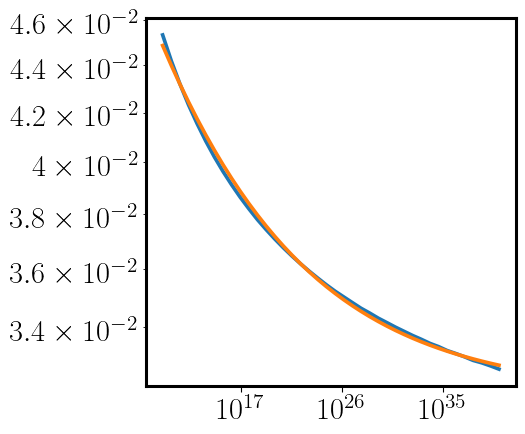

(0.031736405628353795, -0.03879456302454725, 0.031869912923195895)

In [13]:
        data = []
        reltol = 1e-15
        abstol = 1e-15
        pows = range(10.0, 40.0, 40)
        Ns = 10 .^ pows
        r = 0.1
        g = 0.2

        for pow in pows
            N = BigInt(10)^pow
            Nf = Float64(N)
            Γ = 1.0
            ξ = Nf * r
            γ = Nf * g / log(Nf)

            p = [Γ, ξ, Nf, γ]
            u0 = [-log(Nf), 0.5]
            t_end = 100.0 * log(Nf) / Nf

            prob = ODEProblem(meanfield_log_transformed!, u0, (0.0, t_end), p)
            sol = solve(
                prob,
                AutoTsit5(Rosenbrock23()),
                reltol = reltol,
                abstol = abstol,
                saveat = range(0.0, t_end, 30000)
            )

            push!(data, exp(maximum(x -> x[1], sol.u)))
        end

        plot(Ns, data)
        p = best_powerlaw_fit(Ns, data)
        plot(Ns, powerlaw_offset_model(Ns, p...))
        yscale(:log)
        xscale(:log)
        @show p


In [16]:
function powerlaw_fit_with_offset_scan(x, y; Cmin=0.0, Cmax=nothing, nC=200)

    if Cmax === nothing
        Cmax = minimum(y) * 0.99
    end

    lx = log.(x)

    best = nothing
    best_err = Inf

    for C in range(Cmin, Cmax; length=nC)

        yt = y .- C

        any(yt .<= 0) && continue

        ly = log.(yt)

        α = cov(lx, ly) / var(lx)
        b = mean(ly) - α * mean(lx)

        A = exp(b)

        err = mean((ly .- (α .* lx .+ b)).^2)

        if err < best_err
            best_err = err
            best = (A=A, α=α, C=C, err=err)
        end
    end

    return best
end

powerlaw_fit_with_offset_scan (generic function with 1 method)

In [17]:
rs = range(0.0, 1.1, 100)
gs = range(0.0, 0.5, 100)
fit_data = zeros(length(rs), length(gs))
fit_data2 = zeros(length(rs), length(gs))


for (i, r) in enumerate(rs)
    for (j, g) in enumerate(gs)
        @show r,g

        data = []
        reltol = 1e-15
        abstol = 1e-15
        pows = range(23.0, 100.0, 20)
        Ns = 10 .^ pows

        for pow in pows
            N = BigInt(10)^pow
            Nf = Float64(N)
            Γ = 1.0
            ξ = Nf * r
            γ = Nf * g / log(Nf)

            p = [Γ, ξ, Nf, γ]
            u0 = [-log(Nf), 0.5]
            t_end = 100.0 * log(Nf) / Nf

            prob = ODEProblem(meanfield_log_transformed!, u0, (0.0, t_end), p)
            sol = solve(
                prob,
                AutoTsit5(Rosenbrock23()),
                reltol = reltol,
                abstol = abstol,
                saveat = range(0.0, t_end, 30000)
            )

            push!(data, exp(maximum(x -> x[1], sol.u)))
        end

        #plot(Ns, data)
        p = powerlaw_fit_with_offset_scan(Ns, data)
        #plot(Ns, powerlaw_offset_model(Ns, p...))
        #yscale(:log)
        #xscale(:log)

        fit_data[i,j] = p[2]
        fit_data2[i,j] = p[3]
    end
end

(r, g) = (0.0, 0.0)
(r, g) = (0.0, 0.005050505050505051)
(r, g) = (0.0, 0.010101010101010102)
(r, g) = (0.0, 0.015151515151515152)
(r, g) = (0.0, 0.020202020202020204)
(r, g) = (0.0, 0.025252525252525252)
(r, g) = (0.0, 0.030303030303030304)
(r, g) = (0.0, 0.03535353535353535)
(r, g) = (0.0, 0.04040404040404041)
(r, g) = (0.0, 0.045454545454545456)
(r, g) = (0.0, 0.050505050505050504)
(r, g) = (0.0, 0.05555555555555555)
(r, g) = (0.0, 0.06060606060606061)
(r, g) = (0.0, 0.06565656565656566)
(r, g) = (0.0, 0.0707070707070707)
(r, g) = (0.0, 0.07575757575757576)
(r, g) = (0.0, 0.08080808080808081)
(r, g) = (0.0, 0.08585858585858586)
(r, g) = (0.0, 0.09090909090909091)
(r, g) = (0.0, 0.09595959595959595)
(r, g) = (0.0, 0.10101010101010101)
(r, g) = (0.0, 0.10606060606060606)
(r, g) = (0.0, 0.1111111111111111)
(r, g) = (0.0, 0.11616161616161616)
(r, g) = (0.0, 0.12121212121212122)
(r, g) = (0.0, 0.12626262626262627)
(r, g) = (0.0, 0.13131313131313133)
(r, g) = (0.0, 0.13636363636363635)
(r

In [18]:
using JLD2
using PyPlot

@save "../plot_data/fit_results.jld2" rs gs fit_data fit_data2

In [4]:
include("PlotSetup.jl")

using JLD2
using PyPlot

data = load("../plot_data/fit_results.jld2")
rs = data["rs"]
gs = data["gs"]
fit_data = data["fit_data"]
fit_data2 = data["fit_data2"]

test_data = copy(fit_data)
test_data[abs.(fit_data2) .> 1e-5] .= 0.0;

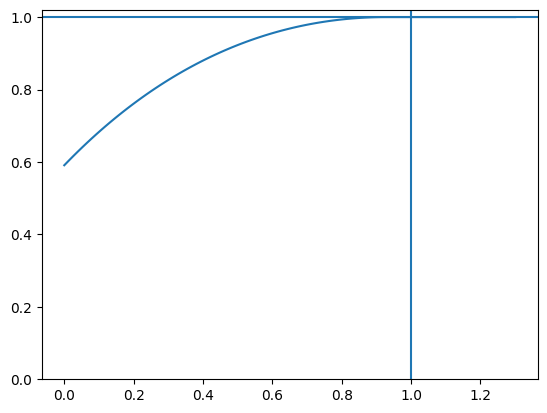

(0.0, 1.0204568546293369)

In [5]:
# Core function F(x)
F(x) = (1 - x) - (1 + x) * log(2 / (1 + x))

# Alpha with finite-N correction
function alpha(gxi, gbar; N=1e100)
    ggamma = 0.0 #gbar / log(N)
    val = 1 - F(gxi + ggamma) / gbar
    if gxi > 1.0
        val = 1.0
    end
    return clamp(val, 0.0, 1.0)
end

plot(range(0.0, 1.3, 100), [alpha(gxi, 0.75; N=1e100) for gxi in range(0.0, 1.4, 100)])
axvline(1.0)
axhline(1.0)
ylim(bottom = 0.0)

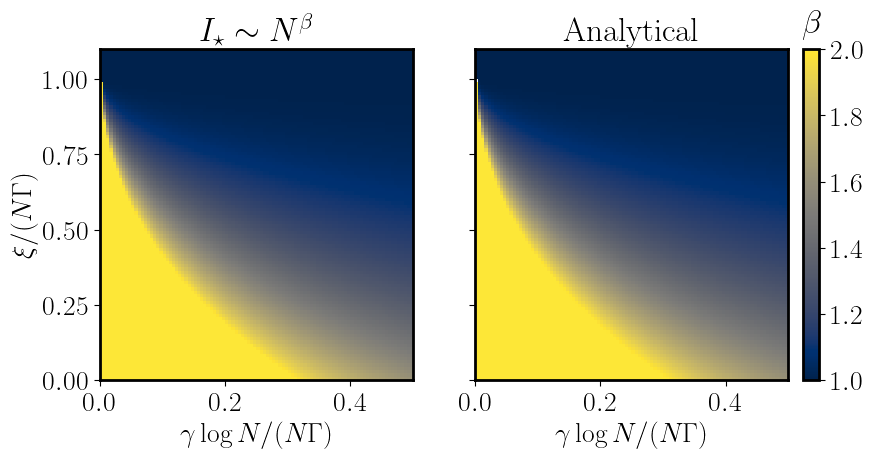

In [6]:
w, h = latex_plot_setup(scale = 2.0, ratio = 0.9)
fig, axes = subplots(ncols = 2, figsize = (2 * w, h), sharey = "row")
im = axes[1].imshow(test_data, origin = "lower", extent = [first(gs), last(gs), first(rs), last(rs)], cmap = "cividis", aspect = "auto", zorder = 1)
sca(axes[1])
gca().set_xlabel(L"\gamma\log N/(N\Gamma)")
gca().set_ylabel(L"\xi/(N\Gamma)")
gca().set_title(L"I_\star\sim N^{\beta}")

an_data = [alpha(gxi, gbar) for gxi in rs, gbar in gs]
im = axes[2].imshow(2.0 .- an_data, origin = "lower", extent = [first(gs), last(gs), first(rs), last(rs)], cmap = "cividis", aspect = "auto")
sca(axes[2])
clb = fig.colorbar(im, ax=axes, location="right", fraction=0.05, pad=0.02)
gca().set_xlabel(L"\gamma\log N/(N\Gamma)")
clb.ax.set_title(L"\beta", pad = 12)
gca().set_title("Analytical")
savefig("../data/alpha_comparison_plot.pdf", bbox_inches = "tight")